In [ ]:
!pip install torchmetrics

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 36.4 MB/s eta 0:00:00


In [ ]:
#import delle librerie
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import h5py
import glob

# pytorch
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

from torch import nn
import torch.nn.functional as F

from torch import optim
from torchmetrics.classification import MulticlassAccuracy

from torchsummary import summary

2.0.1+cu118
0.15.2+cu118


In [ ]:
# mount google drive

from google.colab import drive
drive.mount('/content/drive')

# copy locally the file and uncompress it
from os.path import exists
if exists("JetDataset/") == False:
    !cp /content/drive/MyDrive/MachineLearning/JetDataset.tgz .//   #nello stesso folder devo avere anche tre folder "models", "plots" e "logs"
    !tar xfvz JetDataset.tgz                                        #per salvare i plot, i modelli e i logs dell'allenamento


Mounted at /content/drive
./JetDataset/
./JetDataset/jetImage_7_100p_30000_40000.h5
./JetDataset/jetImage_7_100p_10000_20000.h5
./JetDataset/jetImage_7_100p_80000_90000.h5
./JetDataset/jetImage_7_100p_40000_50000.h5
./JetDataset/jetImage_7_100p_0_10000.h5
./JetDataset/jetImage_7_100p_60000_70000.h5
./JetDataset/jetImage_7_100p_70000_80000.h5
./JetDataset/jetImage_7_100p_50000_60000.h5


# Reading the data

In [ ]:
# data is stored in hirearchical data format (h5), a file format desgined to store and maniuplate large size data structures
# .h5 files can be accesses in python using the h5py library (https://docs.h5py.org/en/stable/)

# read dataset (is it possibile to increase the number of events to read by commenting out the individuals files)
target = np.array([])
jetImage = np.array([])
datafiles = [#'JetDataset/jetImage_7_100p_80000_90000.h5',
             #'JetDataset/jetImage_7_100p_70000_80000.h5',
             #'JetDataset/jetImage_7_100p_60000_70000.h5',
             #'JetDataset/jetImage_7_100p_50000_60000.h5',
             #'JetDataset/jetImage_7_100p_40000_50000.h5',
             'JetDataset/jetImage_7_100p_30000_40000.h5',
             'JetDataset/jetImage_7_100p_10000_20000.h5',
             'JetDataset/jetImage_7_100p_0_10000.h5']


# let's print what is contained in one of the files:
f = h5py.File(datafiles[0])
print(list(f.keys()))
f.close()

# each file contains different numpy arrays, the ones we are interested in are:
# "jetImage": containing for each jet the momentum deposit in a matrix of 100x100 bins centered around the jet axis
# "jets": containing for each jet several (59) global features of the jet, we are here interested in the elements from -6:-1 that provide a onehot encoding of the jet-type label ['j_g', 'j_q', 'j_w', 'j_z', 'j_t]


#loop over the files and concatenate the content to the jetImage and target arrays
for fileIN in datafiles:
    print("Appending %s" %fileIN)
    f = h5py.File(fileIN) #read the h5 file
    data = np.array(f.get("jetImage")) #jet images
    targ = np.array(f.get('jets')[0:,-6:-1])  #select ['j_g', 'j_q', 'j_w', 'j_z', 'j_t] out of the 59 features presents in the container
    jetImage = np.concatenate([jetImage, data], axis=0) if jetImage.size else data
    target = np.concatenate([target, targ], axis=0) if target.size else targ
    del data, targ
    f.close()

print(target.shape, jetImage.shape)


jetLabel = np.argmax(target, axis=1)
labels = ['gluon', 'quark', 'W', 'Z', 'top']

['jetConstituentList', 'jetFeatureNames', 'jetImage', 'jetImageECAL', 'jetImageHCAL', 'jets', 'particleFeatureNames']
Appending JetDataset/jetImage_7_100p_30000_40000.h5
Appending JetDataset/jetImage_7_100p_10000_20000.h5
Appending JetDataset/jetImage_7_100p_0_10000.h5
(30000, 5) (30000, 100, 100)


In [ ]:
# splitting del campione in training, validation e test (60:20:20)

from sklearn.model_selection import train_test_split

X_train, X, Y_train, Y = train_test_split(jetImage, jetLabel, train_size = 0.6, shuffle=True) #training 60%
X_vali, X_test, Y_vali, Y_test = train_test_split(X, Y, train_size = 0.5, shuffle=True) #validation + test sono 50% 50%

print(X_train.shape)
print(Y_train.shape)
print(X_vali.shape)
print(Y_vali.shape)
print(X_test.shape)
print(Y_test.shape)

#Convertire in tensori
X_train_pt = torch.Tensor(X_train).float()
Y_train_pt = torch.Tensor(Y_train).int()
X_vali_pt = torch.Tensor(X_vali).float()
Y_vali_pt = torch.Tensor(Y_vali).int()
X_test_pt = torch.Tensor(X_test).float()
Y_test_pt = torch.Tensor(Y_test).int()

(18000, 100, 100)
(18000,)
(6000, 100, 100)
(6000,)
(6000, 100, 100)
(6000,)


In [ ]:
#Normalization of the data:
X_train_pt += -torch.mean((X_train_pt))
X_train_pt /= torch.std((X_train_pt))
X_vali_pt += -torch.mean((X_vali_pt))
X_vali_pt /= torch.std((X_vali_pt))
X_test_pt += -torch.mean((X_test_pt))
X_test_pt /= torch.std((X_test_pt))

In [ ]:
# controlliamo se la GPU è disponibile e nel caso quale tipo di GPU
if torch.cuda.is_available():
    print('Numero di GPU disponibili: ',torch.cuda.device_count())
    for i in range(0,torch.cuda.device_count()):
        print(torch.cuda.get_device_name(i))

# se la GPU è disponibile setto device='cuda', altrimenti 'cpu
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Numero di GPU disponibili:  1
Tesla T4
Computation device: cuda



In [ ]:
#Dataloader e Dataset
from torch.utils.data import TensorDataset, DataLoader
batch = 100

dataset_train = TensorDataset(X_train_pt, Y_train_pt)
train_dl = DataLoader(dataset_train, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)

dataset_vali = TensorDataset(X_vali_pt, Y_vali_pt)
vali_dl = DataLoader(dataset_vali, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)

dataset_test = TensorDataset(X_test_pt, Y_test_pt)
test_dl = DataLoader(dataset_test, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)

In [ ]:
#base model

class DNN0(nn.Module):
    def __init__(self, input_dim = 10000, output_dim = 5, hidden_dim = 400):
        super(DNN0, self).__init__()

        self.model_name = "DNN0"
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        self.opt = optim.Adam(self.parameters())

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        out = x
        return out

    def compute_loss(self, pred, target):
        loss = F.cross_entropy(pred, target)
        return loss

In [ ]:
#first model
#DNN con layer lineari

class DNN1(nn.Module):
    def __init__(self, input_dim = 10000, output_dim = 5, hidden_dim = 400):
        super(DNN1, self).__init__()

        self.model_name = "DNN1"
        self.flatten = nn.Flatten(1)
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.dropout2 = nn.Dropout(0.2)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout3 = nn.Dropout(0.2)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout4 = nn.Dropout(0.2)
        self.layer4 = nn.Linear(hidden_dim, output_dim)
        self.opt = optim.Adam(self.parameters())

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.layer2(x)
        x = F.relu(x)
        x = self.dropout3(x)
        x = self.layer3(x)
        x = F.relu(x)
        x = self.layer4(x)
        out = x
        return out

    def compute_loss(self, pred, target):
        loss = F.cross_entropy(pred, target)
        return loss


In [ ]:
# model usando un CNN (on half of dataset acc = 74%)
class DNN2(nn.Module):
    def __init__(self, input_dim = 1296, output_dim = 5, hidden_dim = 425):
        super(DNN2, self).__init__()

        self.model_name = "DNN2"
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = (4,4))

        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 16, kernel_size = (4,4))
        self.pool2 = nn.MaxPool2d(kernel_size = (3,3))

        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 16, kernel_size = (4,4))
        self.pool3 = nn.MaxPool2d(kernel_size = (3,3))

        self.flatten = nn.Flatten(start_dim = 1)

        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.dropout2 = nn.Dropout(0.2)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout3 = nn.Dropout(0.2)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout4 = nn.Dropout(0.2)
        self.layer4 = nn.Linear(hidden_dim, output_dim)
        self.opt = optim.Adam(self.parameters())

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.flatten(x)

        x = self.layer1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.layer2(x)
        x = F.relu(x)
        x = self.dropout3(x)
        x = self.layer3(x)
        x = F.relu(x)
        out = self.layer4(x)
        return out

    def compute_loss(self, pred, target):
        loss = F.cross_entropy(pred, target)
        return loss

In [ ]:
# model similar to the one from paper, but using a CNN
class DNN3(nn.Module):
    def __init__(self, input_dim = 576, output_dim = 5, hidden_dim = 425):
        super(DNN3, self).__init__()

        self.model_name = "DNN3"
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = (4,4))

        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 16, kernel_size = (4,4))
        self.pool2 = nn.MaxPool2d(kernel_size = (3,3))

        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 16, kernel_size = (4,4))
        self.pool3 = nn.MaxPool2d(kernel_size = (3,3))

        self.conv4 = nn.Conv2d(in_channels = 16, out_channels = 64, kernel_size = (4,4))
        self.pool4 = nn.MaxPool2d(kernel_size = (2,2))

        self.flatten = nn.Flatten(start_dim = 1)

        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.layer4 = nn.Linear(hidden_dim, output_dim)
        self.opt = optim.Adam(self.parameters())

        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.2)


    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = self.dropout1(x)
        x = F.relu(self.conv2(x))
        x = self.dropout1(x)
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.dropout1(x)
        x = self.pool3(x)
        x = F.relu(self.conv4(x))
        x = self.dropout1(x)
        x = self.pool4(x)
        x = self.flatten(x)

        x = self.layer1(x)
        x = F.tanh(x)
        x = self.dropout2(x)
        x = self.layer2(x)
        x = F.tanh(x)
        x = self.dropout2(x)
        x = self.layer3(x)
        x = F.tanh(x)
        x = self.dropout2(x)
        x = self.layer4(x)

        out = x
        return out

    def compute_loss(self, pred, target):
        loss = F.cross_entropy(pred, target)
        return loss

In [ ]:
#definisco locally connected layer
from torch.nn.modules.utils import _pair

class LocallyConnected2d(nn.Module):
    def __init__(self, in_channels, out_channels, output_size, kernel_size, stride, bias=False):
        super(LocallyConnected2d, self).__init__()
        output_size = _pair(output_size) #in questo modo ho sempre 2 valori in out
        self.weight = nn.Parameter(
            torch.randn(1, out_channels, in_channels, output_size[0], output_size[1], kernel_size**2)
        )
        if bias:
            self.bias = nn.Parameter(
                torch.randn(1, out_channels, output_size[0], output_size[1])
            )
        else:
            self.register_parameter('bias', None) #il modello non ha un parametro di bias
        self.kernel_size = _pair(kernel_size)
        self.stride = _pair(stride)

    def forward(self, x):
        _, c, h, w = x.size() # x ha dimensione (batch_size, channels, height, width)
        kh, kw = self.kernel_size
        dh, dw = self.stride
        x = x.unfold(2, kh, dh).unfold(3, kw, dw) #faccio unfold perché in questo modo é piú facile operare sulle diverse regioni del dato
        x = x.contiguous().view(*x.size()[:-2], -1) #flatten
        # Sum in in_channel and kernel_size dims
        out = (x.unsqueeze(1) * self.weight).sum([2, -1])
        if self.bias is not None:
            out += self.bias
        return out

In [ ]:
# modello con locally connected layer
class DNN4(nn.Module):
    def __init__(self, input_dim = 7744, output_dim = 5, hidden_dim = 425):
        super(DNN4, self).__init__()

        self.model_name = "DNN4"
        self.local1 = LocallyConnected2d(in_channels=1, out_channels=16, output_size = 97, kernel_size=4, stride = 1)
        self.dropout1 = nn.Dropout(0.1)

        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 16, kernel_size = (4,4))
        #dropout
        self.pool2 = nn.MaxPool2d(kernel_size = (2,2))

        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 16, kernel_size = (4,4))
        #dropout
        self.pool3 = nn.MaxPool2d(kernel_size = (2,2))

        self.flatten = nn.Flatten(start_dim = 1)

        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.dropout2 = nn.Dropout(0.3)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout3 = nn.Dropout(0.2)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout4 = nn.Dropout(0.3)
        self.layer4 = nn.Linear(hidden_dim, output_dim)
        self.opt = optim.Adam(self.parameters())

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.local1(x))
        x = self.dropout2(x)
        x = F.relu(self.conv2(x))
        x = self.dropout3(x)
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.dropout1(x)
        x = self.pool3(x)
        x = self.flatten(x)

        x = self.layer1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        x = self.layer2(x)
        x = F.relu(x)
        x = self.dropout1(x)
        x = self.layer3(x)
        x = F.relu(x)
        out = self.layer4(x)
        return out

    def compute_loss(self, pred, target):
        loss = F.cross_entropy(pred, target)
        return loss

In [ ]:
#Test del model
def test_model(model):
    feat, label = next(iter(train_dl))
    feat = feat.to(device)
    label = label.to(device)
    model.to(device)
    out = model(feat)

    print("Features:",feat.shape)
    print("Labels:",label.shape)
    print("Out:", out.shape)

In [ ]:
def plot_output(hist_loss, hist_vloss, hist_metric, hist_vmetric, model_name):
    #loss plot
    fig = plt.figure(figsize=(10, 7))
    plt.plot(range(1,len(hist_loss)+1), hist_loss, color='green', linestyle='-', label='train loss')
    plt.plot(range(1,len(hist_vloss)+1), hist_vloss, color='blue', linestyle='-', label='validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title("Validation and training loss, "+model_name)
    fig.savefig("drive/MyDrive/MachineLearning/plots/"+model_name+"loss.png")
    plt.show()


    #metric plot
    fig = plt.figure(figsize=(10, 7))
    plt.plot(range(1,len(hist_metric)+1),hist_metric, color='green', linestyle='-', label='train metric')
    plt.plot(range(1,len(hist_vmetric)+1),hist_vmetric, color='blue', linestyle='-', label='validation metric')
    plt.xlabel('Epochs')
    plt.ylabel('Metric')
    plt.legend()
    plt.title("Validation and training accuracy, "+model_name)
    fig.savefig("drive/MyDrive/MachineLearning/plots/"+model_name+"metric.png")
    plt.show()


In [ ]:
def run_model(model, epochs = 50, do_plot = True, give_output = False, save_model = True, save_logs = True):
    import time
    metric_func = metric_func = MulticlassAccuracy(5).to(device)

    # numero di epoche

    hist_loss = []
    hist_metric = []
    hist_vloss = []
    hist_vmetric = []

    model.to(device)
    # loop sulle epoche
    for epoch in range(epochs):
        t0 = time.time()

        # training step
        model.train()
        train_loss = 0
        train_metric = 0
        counter = 0

        for xb, yb in train_dl:
            counter += 1
            xb=xb.to(device)
            yb=yb.type(torch.LongTensor).to(device)

            pred = model(xb)
            # calcolo loss e metrica
            loss = model.compute_loss(pred, yb)
            metric = metric_func(pred, yb)


            # aggiorno la loss e metrica totale
            train_loss += loss.item()
            train_metric += metric.item()

            # backpropagation
            model.opt.zero_grad() #resetta i gradienti prima di eseguire la backpropagation
            loss.backward() #calcola i gradienti della loss
            model.opt.step() #aggiorna i pesi


        train_loss /= counter
        train_metric /= (counter)

        hist_loss.append(train_loss)
        hist_metric.append(train_metric)

        # validation step (non vengono aggiornati i pesi)
        model.eval()
        vali_loss = 0
        vali_metric = 0
        counter = 0
        with torch.no_grad(): #evita che si aggiornino i pesi
            for xb, yb in vali_dl:
                counter += 1
                xb=xb.to(device)
                yb=yb.type(torch.LongTensor).to(device)

                pred = model(xb) #predizione del modello

                # calcolo loss e metrica
                vloss = model.compute_loss(pred, yb)
                vmetric = metric_func(pred, yb)
                vali_loss += vloss.item()
                vali_metric += vmetric.item()

        vali_loss /= counter
        vali_metric /= (counter)
        hist_vloss.append(vali_loss)
        hist_vmetric.append(vali_metric)

        elapsed_time = time.time()-t0
        print("epoch: %d, time(s): %.4f, train loss: %.6f, train metric: %.6f, vali loss: %.6f, vali metric: %.6f"
            % (epoch+1, elapsed_time, train_loss, train_metric, vali_loss, vali_metric))

        if save_model == True:
            if hist_vmetric[-1] == max(hist_vmetric):
                torch.save(model.state_dict(), f = "drive/MyDrive/MachineLearning/models/state_dict_"+model.model_name+".pth")
                best_epoch = len(hist_vmetric)
    print(f"Best model at epoch {best_epoch}, with accuracy on vali set of {hist_vmetric[best_epoch-1]:.6f}")

    if do_plot == True:
        plot_output(hist_loss, hist_vloss, hist_metric, hist_vmetric, model.model_name)

    if give_output == True:
        return hist_loss, hist_vloss, hist_metric, hist_vmetric

    if save_logs == True:
        A = np.array([hist_loss, hist_vloss, hist_metric, hist_vmetric])
        np.savetxt("drive/MyDrive/MachineLearning/logs/"+model.model_name+"_training_logs.csv", A, fmt = "%f", delimiter = " ",
                  header = "hist_loss  hist_vloss  hist_metric  hist_vmetric")


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd
def run_on_test(model):
    #load bestperforming model
    model.load_state_dict(torch.load("drive/MyDrive/MachineLearning/models/state_dict_"+model.model_name+".pth"))
    model.eval()
    model.to(device)
    Y_real = np.array([])
    Y_pred = np.array([])
    for xb, yb in test_dl:
        xb = xb.to(device)
        Y_real = np.append(Y_real, yb.numpy())
        y_pred = model(xb).to("cpu")
        Y_pred = np.append(Y_pred, np.argmax(y_pred.detach().numpy(), axis = 1))

    cf_matrix = confusion_matrix(Y_real, Y_pred)
    acc = np.trace(cf_matrix)/Y_test.shape[0]
    print("Confusion_matrix", cf_matrix)
    print("Accuracy", acc)

    df_cm = pd.DataFrame(cf_matrix , index = [i for i in labels],
                     columns = [i for i in labels])
    plt.figure(figsize = (12,7))
    snplot = sn.heatmap(df_cm, annot=True, fmt = "d")
    plt.title("Confusion matrix on test set: " +model.model_name)
    plt.xlabel("Predicted label")
    plt.ylabel("Real label")
    fig = snplot.get_figure()
    fig.savefig("drive/MyDrive/MachineLearning/plots/"+model.model_name+"_conf_matrix.png") #salva il plot nel drive


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                [-1, 10000]               0
            Linear-2                  [-1, 400]       4,000,400
            Linear-3                    [-1, 5]           2,005
Total params: 4,002,405
Trainable params: 4,002,405
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.04
Forward/backward pass size (MB): 0.08
Params size (MB): 15.27
Estimated Total Size (MB): 15.39
----------------------------------------------------------------
Features: torch.Size([100, 100, 100])
Labels: torch.Size([100])
Out: torch.Size([100, 5])
epoch: 1, time(s): 2.0697, train loss: 1.202494, train metric: 0.513720, vali loss: 1.091261, vali metric: 0.553024
epoch: 2, time(s): 1.9579, train loss: 1.013361, train metric: 0.606111, vali loss: 1.043347, vali metric: 0.597419
epoch: 3, time(s): 1.9090, train l

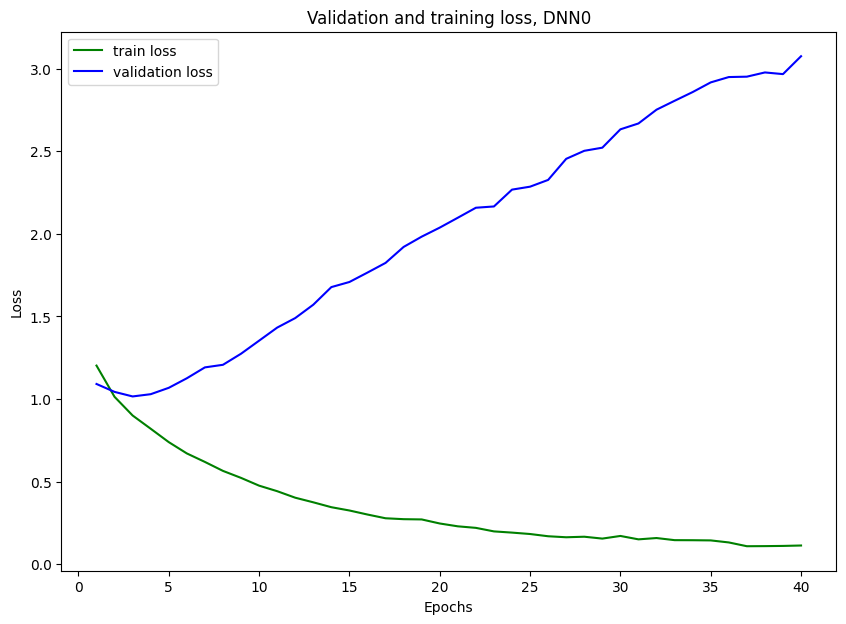

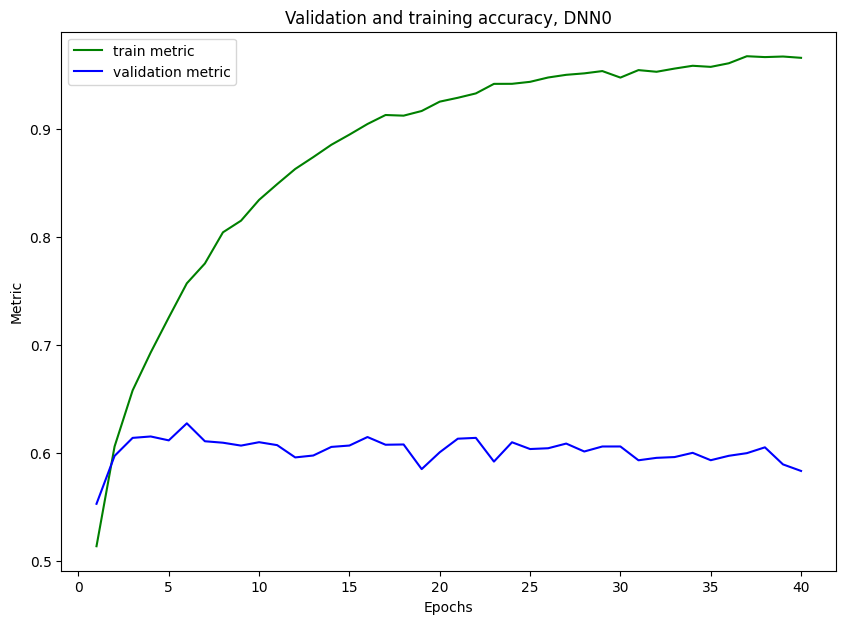

Confusion_matrix [[665 219 100  84 148]
 [170 774 102  58  71]
 [ 82 122 812 202   5]
 [ 92  97 263 725   9]
 [143  50  85 117 805]]
Accuracy 0.6301666666666667


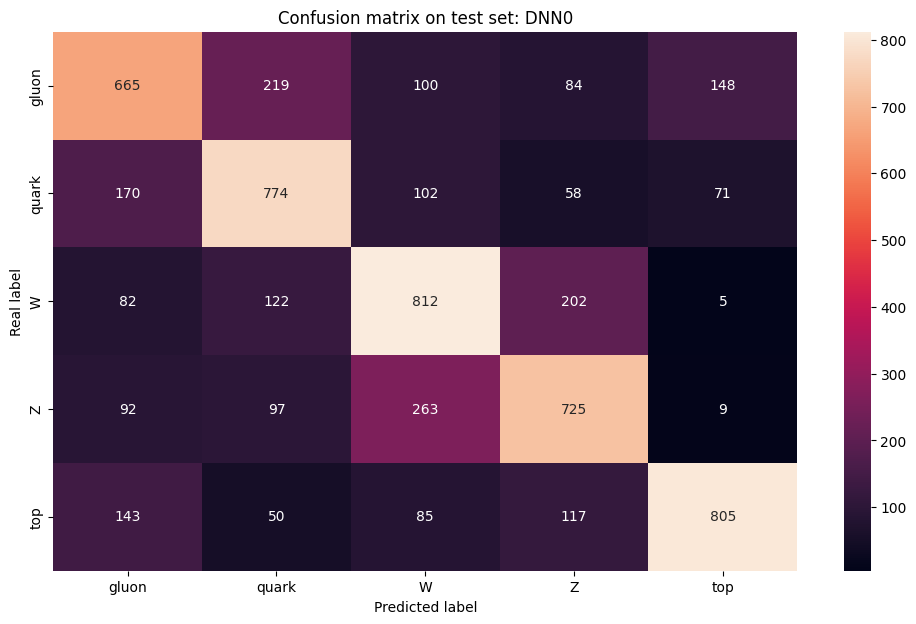

In [ ]:
model0 = DNN0().to(device)
summary(model0, input_size = (100,100))
test_model(model0)
run_model(model0, epochs = 40)
run_on_test(DNN0())

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                [-1, 10000]               0
            Linear-2                  [-1, 400]       4,000,400
           Dropout-3                  [-1, 400]               0
            Linear-4                  [-1, 400]         160,400
           Dropout-5                  [-1, 400]               0
            Linear-6                  [-1, 400]         160,400
            Linear-7                    [-1, 5]           2,005
Total params: 4,323,205
Trainable params: 4,323,205
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.04
Forward/backward pass size (MB): 0.09
Params size (MB): 16.49
Estimated Total Size (MB): 16.62
----------------------------------------------------------------
Features: torch.Size([100, 100, 100])
Labels: torch.Size([100])
Out: torch.Size([100, 5])
epoch: 1, 

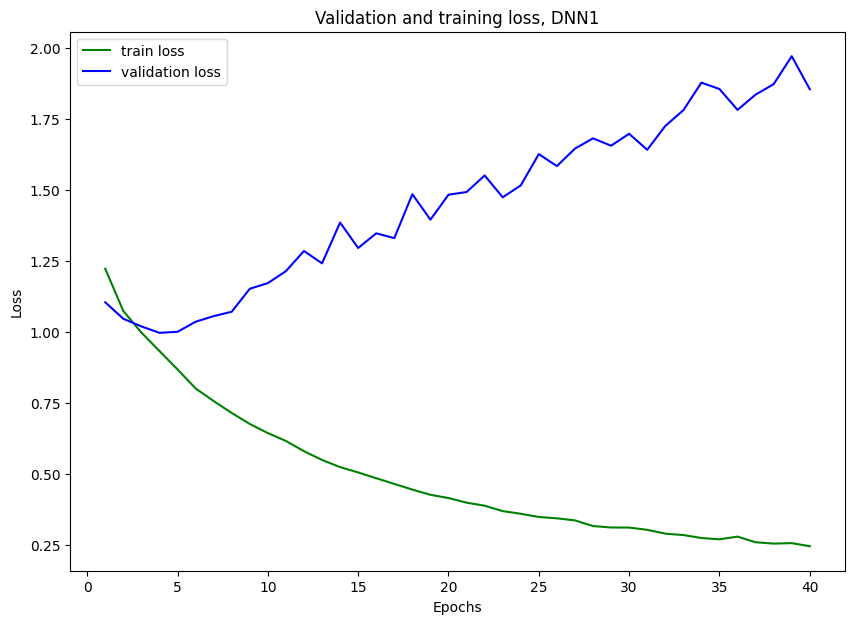

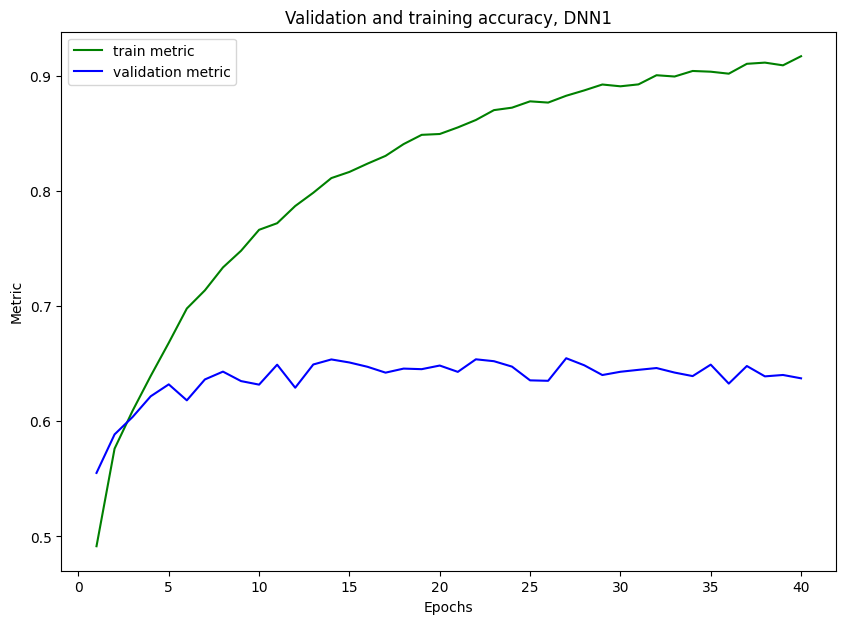

Confusion_matrix [[708 180  65  85 178]
 [171 795  48  51 110]
 [ 77 142 749 211  44]
 [ 67 107 210 734  68]
 [109  46  54  90 901]]
Accuracy 0.6478333333333334


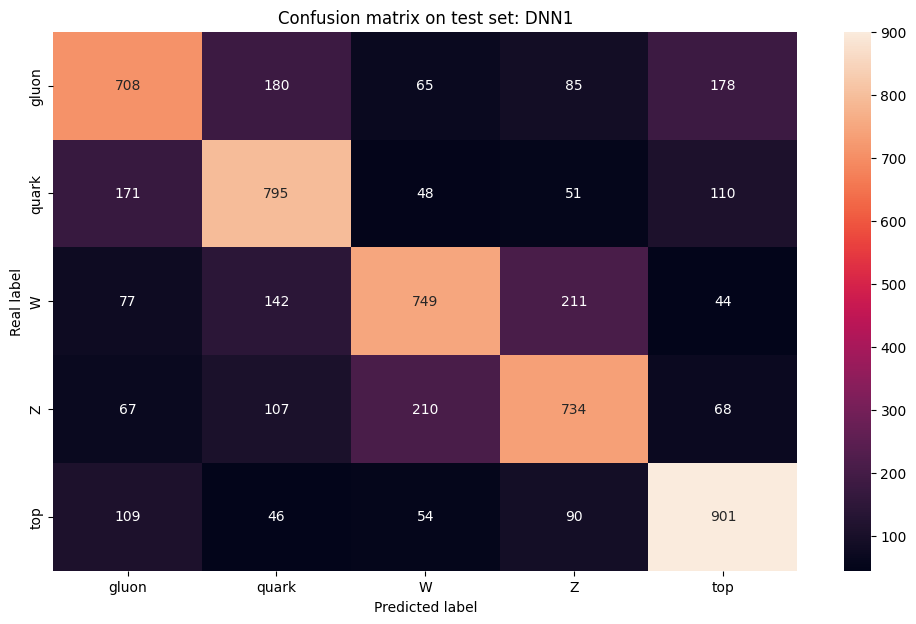

In [ ]:
model1 = DNN1().to(device)
summary(model1, input_size = (100,100))
test_model(model1)
run_model(model1, epochs = 40)
run_on_test(DNN1())

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 97, 97]             272
            Conv2d-2           [-1, 16, 94, 94]           4,112
         MaxPool2d-3           [-1, 16, 31, 31]               0
            Conv2d-4           [-1, 16, 28, 28]           4,112
         MaxPool2d-5             [-1, 16, 9, 9]               0
           Flatten-6                 [-1, 1296]               0
            Linear-7                  [-1, 425]         551,225
           Dropout-8                  [-1, 425]               0
            Linear-9                  [-1, 425]         181,050
          Dropout-10                  [-1, 425]               0
           Linear-11                  [-1, 425]         181,050
           Linear-12                    [-1, 5]           2,130
Total params: 923,951
Trainable params: 923,951
Non-trainable params: 0
-------------------------------

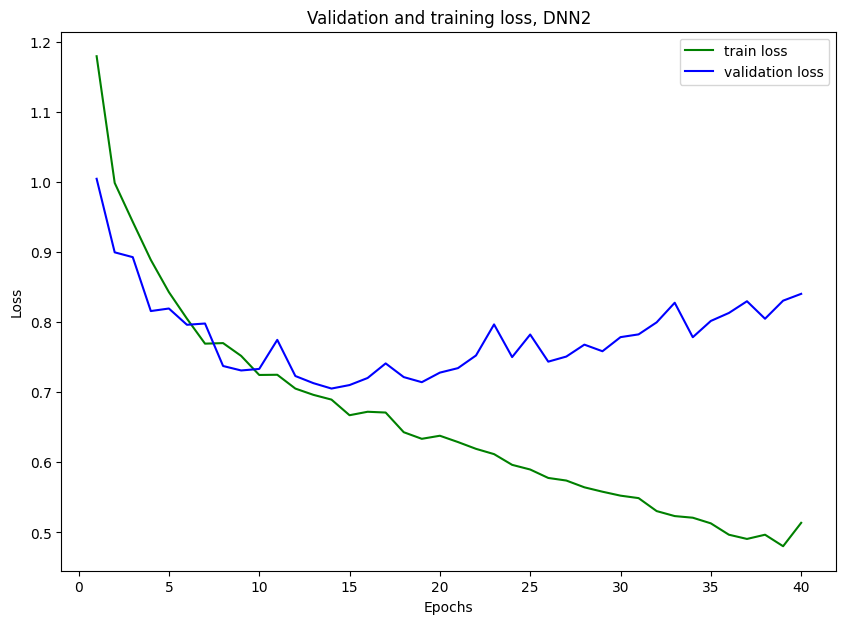

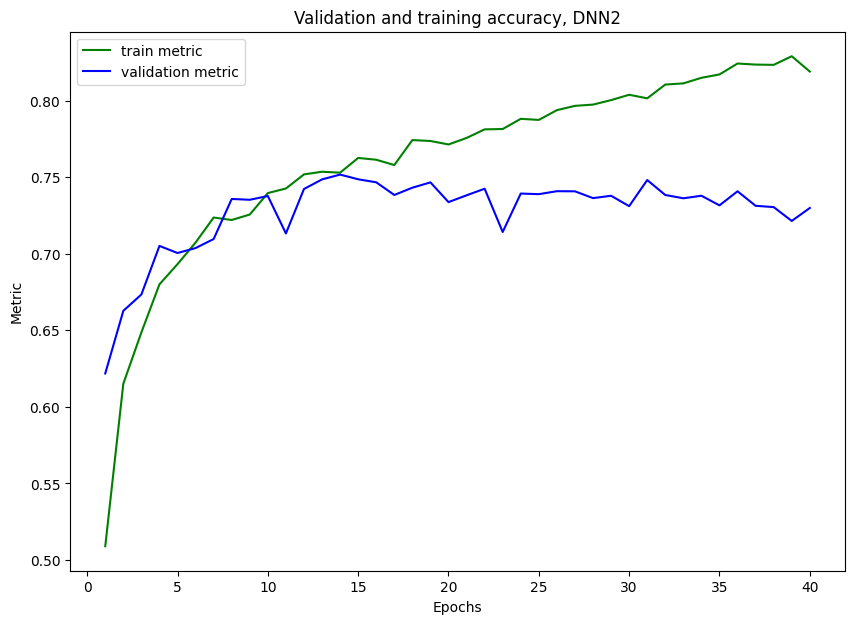

Confusion_matrix [[914 130  23  37 112]
 [202 784  43  51  95]
 [ 56 119 977  61  10]
 [ 44  82 213 834  13]
 [ 89  28  50  61 972]]
Accuracy 0.7468333333333333


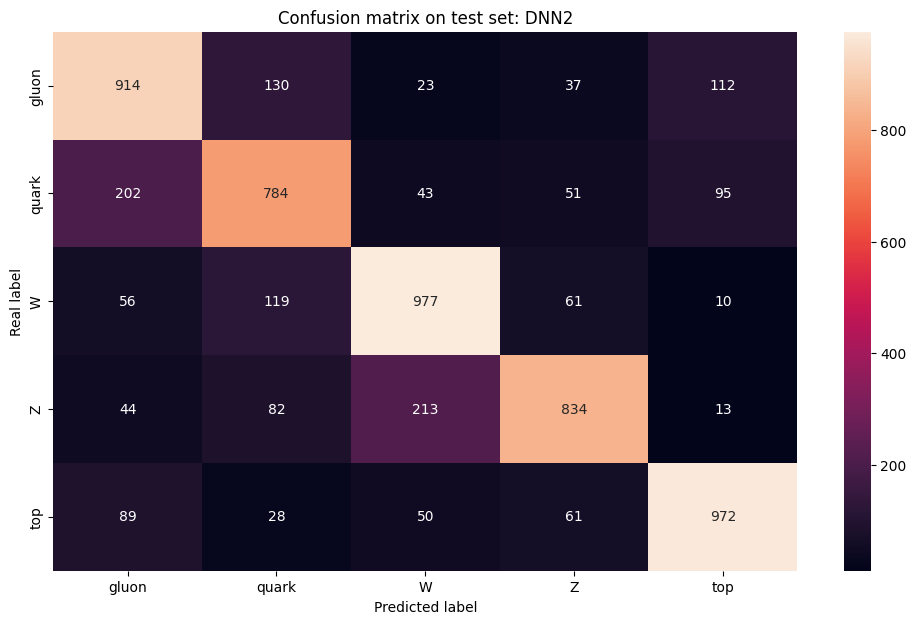

In [ ]:
model2 = DNN2().to(device)
summary(model2, input_size = (100,100))
test_model(model2)
run_model(model2, epochs = 40)
run_on_test(DNN2())

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 97, 97]             272
           Dropout-2           [-1, 16, 97, 97]               0
            Conv2d-3           [-1, 16, 94, 94]           4,112
           Dropout-4           [-1, 16, 94, 94]               0
         MaxPool2d-5           [-1, 16, 31, 31]               0
            Conv2d-6           [-1, 16, 28, 28]           4,112
           Dropout-7           [-1, 16, 28, 28]               0
         MaxPool2d-8             [-1, 16, 9, 9]               0
            Conv2d-9             [-1, 64, 6, 6]          16,448
          Dropout-10             [-1, 64, 6, 6]               0
        MaxPool2d-11             [-1, 64, 3, 3]               0
          Flatten-12                  [-1, 576]               0
           Linear-13                  [-1, 425]         245,225
          Dropout-14                  [

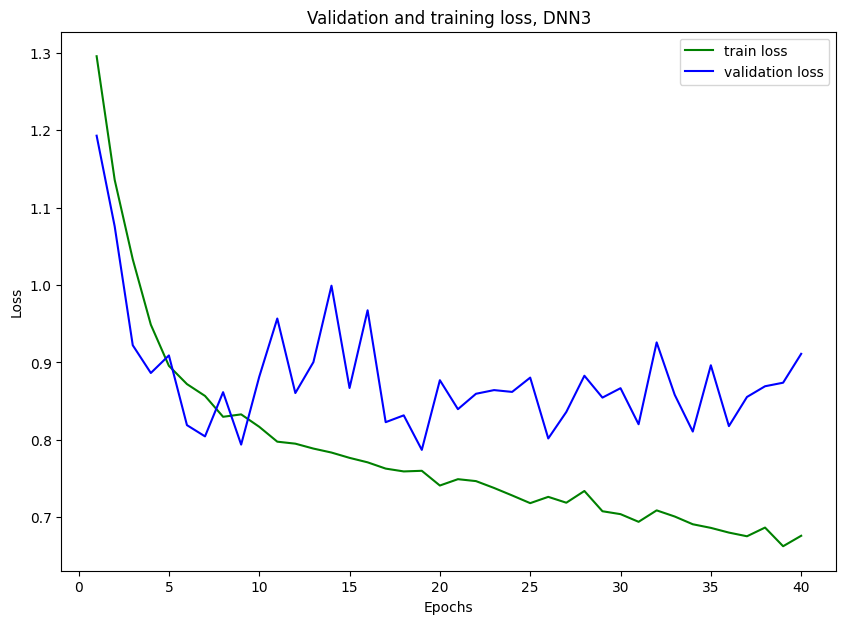

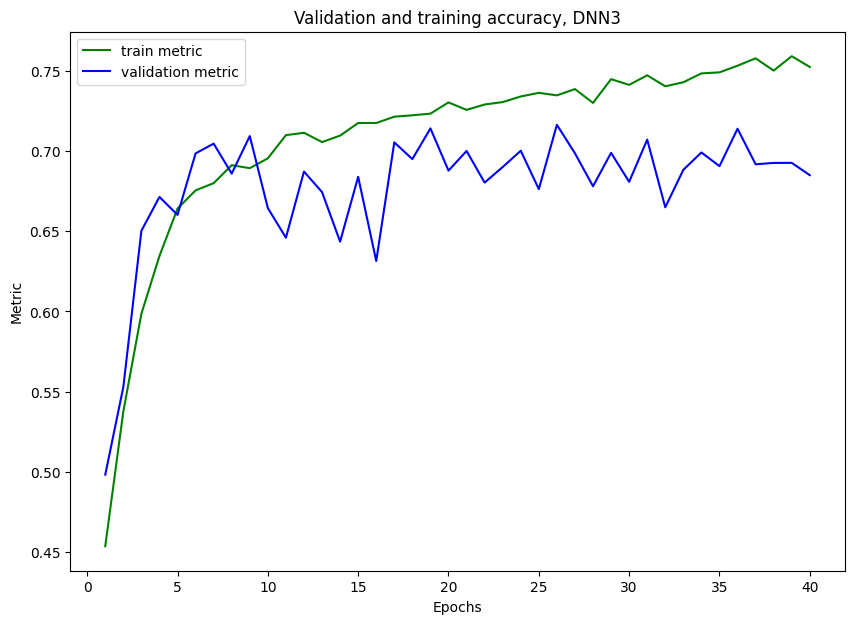

Confusion_matrix [[ 673  259   27   54  203]
 [  86  868   44   47  130]
 [  21  157  941   78   26]
 [  20  103  258  731   74]
 [  55   31   39   48 1027]]
Accuracy 0.7066666666666667


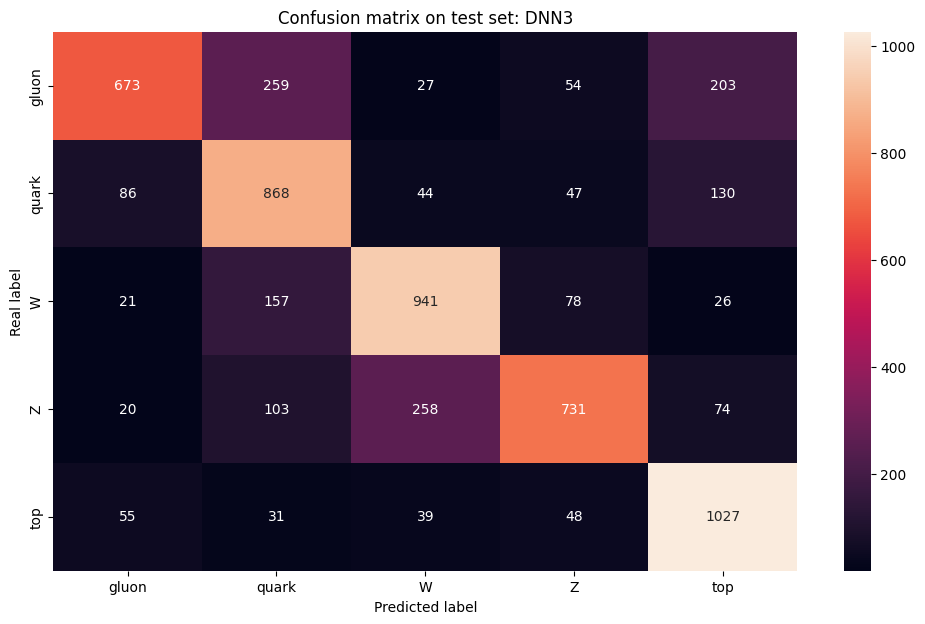

In [ ]:
model3 = DNN3().to(device)
summary(model3, input_size = (100,100))
test_model(model3)
run_model(model3, epochs = 40)
run_on_test(DNN3())

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
LocallyConnected2d-1           [-1, 16, 97, 97]       2,408,704
           Dropout-2           [-1, 16, 97, 97]               0
            Conv2d-3           [-1, 16, 94, 94]           4,112
           Dropout-4           [-1, 16, 94, 94]               0
         MaxPool2d-5           [-1, 16, 47, 47]               0
            Conv2d-6           [-1, 16, 44, 44]           4,112
           Dropout-7           [-1, 16, 44, 44]               0
         MaxPool2d-8           [-1, 16, 22, 22]               0
           Flatten-9                 [-1, 7744]               0
           Linear-10                  [-1, 425]       3,291,625
          Dropout-11                  [-1, 425]               0
           Linear-12                  [-1, 425]         181,050
          Dropout-13                  [-1, 425]               0
           Linear-14                  [

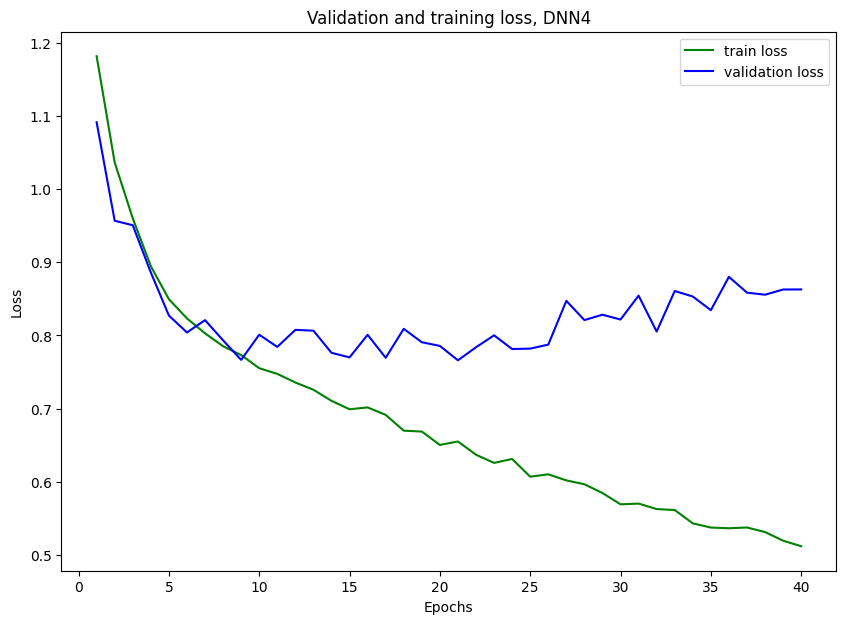

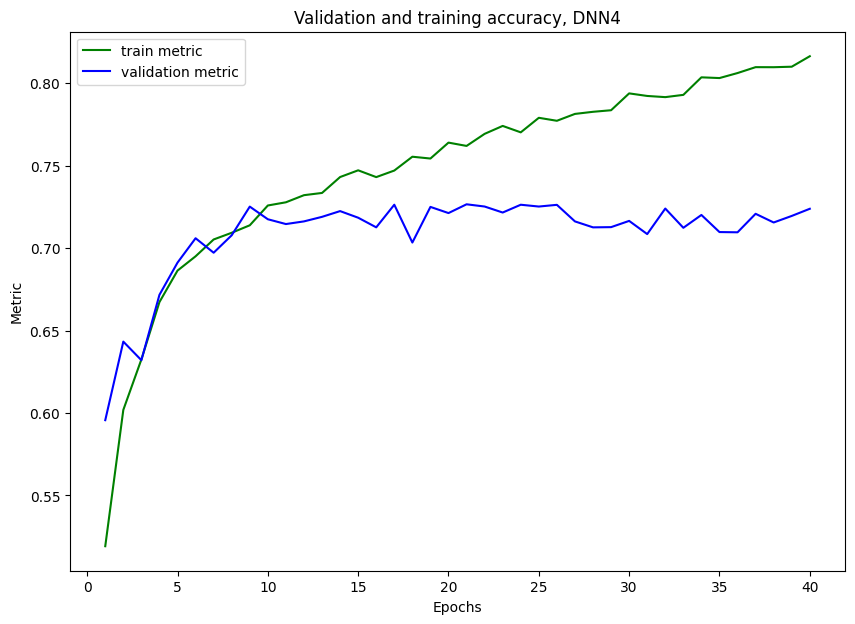

Confusion_matrix [[843 180  37  29 127]
 [190 827  42  35  81]
 [ 32 120 929 130  12]
 [ 37  87 174 867  21]
 [ 96  61  41  66 936]]
Accuracy 0.7336666666666667


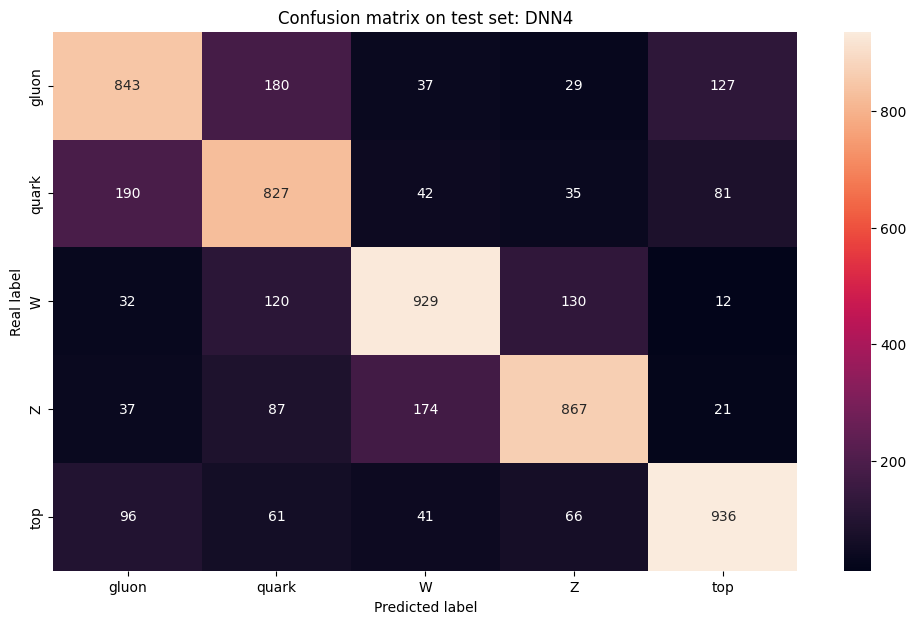

In [ ]:
model4 = DNN4().to(device)
summary(model4, input_size = (100,100))
test_model(model4)
run_model(model4, epochs = 40)
run_on_test(DNN4())